# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Buhangin, Ahrystan Deniz)_: 
- _Student No._: 2024-07766
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="./Figures/derivatives_error.png" alt="abs error vs step size" width=80%>



### Report discussion

The figure shows that as step size becomes increasingly smaller, the central derivative produces a more accurate approximation of the analytical derivative compared to both forward and backward derivatives. The central derivative achieves this greater degree of accuracy due to its error's dependece on h^2 as opposed to just h. This does not mean, however, that forward and backward derivatives are completely of no use. Forward derivatives are still used in cases where we only have access to current and incoming data, and backward derivatives are used in cases where we only have access to past and current data.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

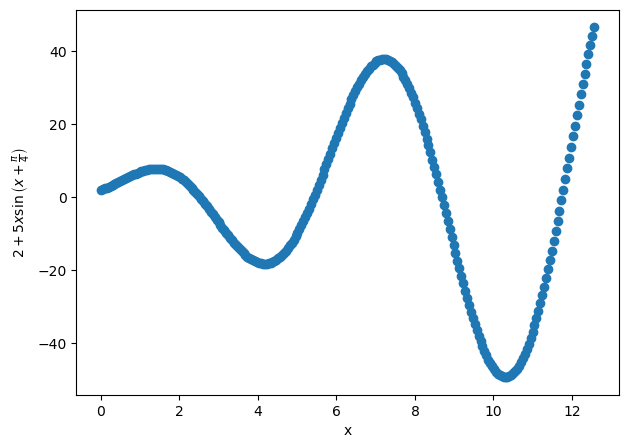

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
n = 257
x = np.linspace(0, 4*np.pi, n)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

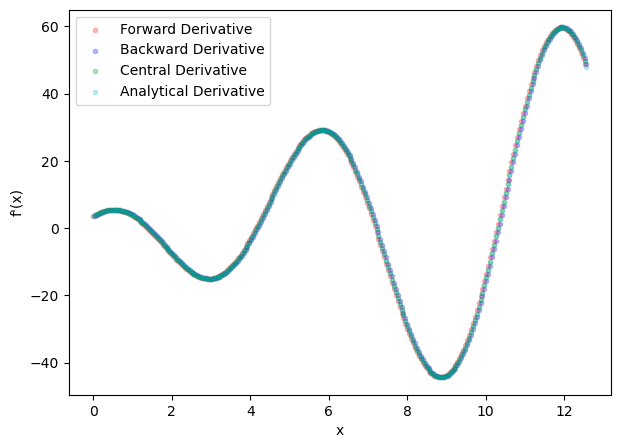

In [3]:
def forward_derivative(x):
    fp = []
    for i in range(x.size - 1):
        h = x[i+1] - x[i]
        xp = (f_0(x[i+1]) - f_0(x[i])) / h
        fp.append(xp)
    forward = np.array(fp)
    return forward

def backward_derivative(x):
    fp = []
    for i in range(x.size - 1):
        h = x[i+1] - x[i]
        xp = (f_0(x[i+1]) - f_0(x[i])) / h
        fp.append(xp)
    backward = np.array(fp)
    return backward

''' 
It can be noted that the function calculating theforward and backward derivatives are exactly the same, 
we need only to apply their uniqueness when assigning them to their corresponding x values. We do this
by simply choosing to remove either the first element or the last element of our input array x.
'''

def central_derivative(x):
    fp = []
    for i in range(x.size - 2):
        h = x[i+1] - x[i]
        xp = (f_0(x[i+2]) - f_0(x[i])) / (2*h)
        fp.append(xp)
    central = np.array(fp)
    return central

def analytical_derivative(x):
    return 5 * np.sin(x + np.pi/4) + 5*x*np.cos(x + np.pi/4)

remove = [0, x.size-1]
fig, ax = plt.subplots(figsize = (7, 5))
ax.scatter(np.delete(x, x.size-1), forward_derivative(x), label='Forward Derivative', c='r', marker='.', alpha=0.25)
ax.scatter(np.delete(x, 0), backward_derivative(x), label='Backward Derivative', c='b', marker='.', alpha=0.25)
ax.scatter(np.delete(x, remove), central_derivative(x), label='Central Derivative', c='g', marker='.', alpha=0.25)
ax.scatter(x, analytical_derivative(x), label='Analytical Derivative', c='c', marker ='.', alpha=0.25)
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
plt.legend()
fig.show()




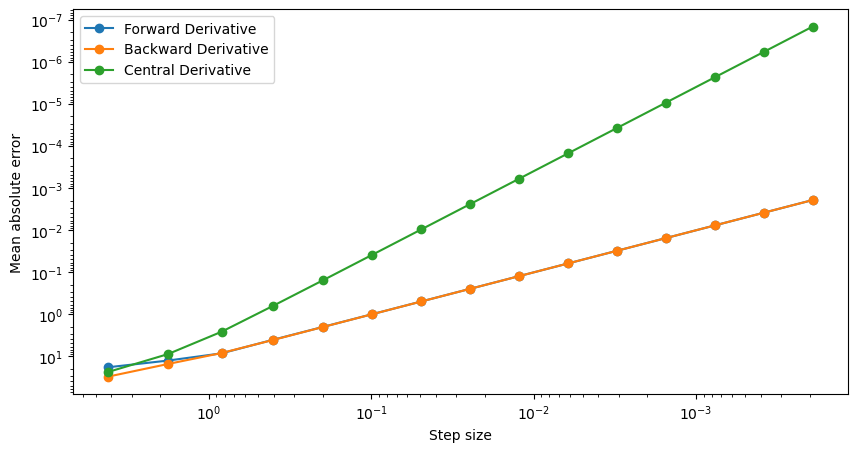

In [4]:
def abs_error(fd, bd, cd, ad):
    fd_err = np.abs(fd - np.delete(ad, x.size-2))
    bd_err = np.abs(bd - np.delete(ad, 0))
    cd_err = np.abs(cd - np.delete(ad, remove))
    fd_merr, bd_merr, cd_merr = np.mean(fd_err), np.mean(bd_err), np.mean(cd_err)
    return fd_merr, bd_merr, cd_merr

N=[2**i for i in range(2, 17)]
s = []
fd_errs = []
bd_errs = []
cd_errs = []

for n in N:
    x = np.linspace(0, 4*np.pi, n)
    remove = [0, x.size-1]
    s.append(np.abs(x[1]-x[0]))
    f, b, c = abs_error(forward_derivative(x), backward_derivative(x), central_derivative(x), analytical_derivative(x))
    fd_errs.append(f)
    bd_errs.append(b)
    cd_errs.append(c)

fig, ax = plt.subplots(figsize = (10, 5))
ax.loglog(s, fd_errs, label='Forward Derivative', marker='o')
ax.loglog(s, bd_errs, label='Backward Derivative', marker='o')
ax.loglog(s, cd_errs, label='Central Derivative', marker='o')
ax.set_xlabel("Step size")
ax.set_ylabel("Mean absolute error")
plt.legend()
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.savefig('/home/jovyan/Buhangin_AP155/AP155_TX1_1sAY2627/ahrystanB/Figures/derivatives_error.png')


#### Problem 1 code summary

The above code contains three implementations of numerical derivative calculations--the forward, backward, and central derivatives. Also implemented was a function to calculate the mean absolute errors of the three approximations, along with an algorithm to construct a set of data points which allow us to visualize the error propagation in each of these methods.

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [5]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
